In [1]:
import pandas as pd
import numpy as np
import pyvinecopulib as pv
import matplotlib.pyplot as plt


from pandas_datareader import data as pdr
from scipy.stats import t
import helper_cp as hpc

# Download data

In [3]:
tickers = ["^DAX", "^SPX", "^NDQ", "10YDEY.B", "10YUSY.B"]  # stooq uses lowercase for US "PLOPLN3M"
start = "2016-01-01"
end = "2026-01-01"

dfs = {}
for t in tickers:
    df = pdr.DataReader(t, "stooq", start, end)   # returns newest->oldest
    print(t)
    df = df.sort_index()
    dfs[t.upper()] = df["Close"].rename(t.upper())

closes = pd.concat(dfs.values(), axis=1).dropna()

^DAX
^SPX
^NDQ
10YDEY.B
10YUSY.B


# Prepare data

In [ ]:
# read data
# Fallback data, we will eventually use the indices data when we gather all of it
# data = pd.read_excel("10_asset_prices.xlsx").set_index("Date")
data = closes
log_data = hpc.to_log_returns(data)
# If we only want monthly data we can resample
# monthly = (1 + data).resample("M").prod() - 1

# standardize data
data_standard = (log_data - log_data.mean()) / log_data.std()

In [ ]:
df = data_standard.copy()
df = df.apply(lambda col: hpc.t_winsorize(col))

U = pv.to_pseudo_obs(df.to_numpy())

controls = pv.FitControlsVinecop(
    family_set = [
        pv.student, pv.gaussian,
        pv.clayton, pv.gumbel
        # pv.frank, pv.joe
    ],
    # trunc_lvl = 3,
    select_trunc_lvl = True,
    show_trace = False
)

cop = pv.Vinecop.from_data(U, controls = controls)

In [16]:
number_of_assets = data_standard.shape[1]
N = 252
sim = 1000
n_sim = N * sim

In [17]:
u_sim = cop.simulate(n_sim)

In [18]:
x_sim = np.asarray([np.quantile(df.to_numpy()[:, i], u_sim[:, i]) for i in range(0, number_of_assets)])
Usim_vine = x_sim.reshape(sim, N, number_of_assets).transpose(1,0,2)

cols = df.columns

simulated_dict_vine = {
    col: pd.DataFrame(index = range(N),
        columns = [f"sim_{i}" for i in range(sim)],
        dtype = float)
    for col in cols
}

for j, col in enumerate(cols):
    U_asset = Usim_vine[:,:,j]
    simulated_dict_vine[col].loc[:,:] = U_asset

In [ ]:
# This is wrong but just a placeholder for now, we recalibrate with mean and vol
recalibrated_sim = hpc.recalibrate_returns(simulated_dict_vine, log_data.mean(), log_data.std())

In [28]:
asset_index_dict_vine["^DAX"].index#.dtype

RangeIndex(start=0, stop=252, step=1)

In [ ]:
asset_index_dict_vine = hpc.prepare_dictionary_of_assets(recalibrated_sim)
mdd_vine, mdd_step_vine = hpc.calculate_mdd_for_sim(asset_index_dict_vine)

In [38]:
np.quantile(mdd_vine["^DAX"], q = 0.99)

np.float64(0.31003519634172144)

# for VaR

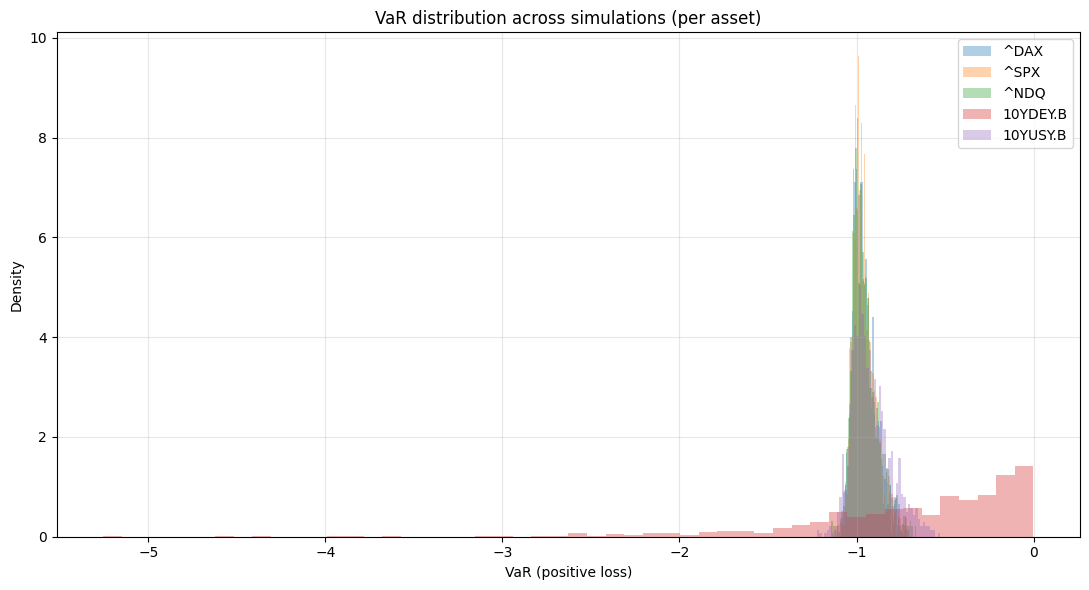

Pooled 95th percentile across all assets/sims: -0.18351206608407322


In [ ]:
# returns_dict = {"AssetA": dfA, "AssetB": dfB, ...}  # each df: rows=time, cols=simulations
var_by_asset = hpc.var_dict(asset_index_dict_vine, alpha=0.05)

# 95th percentile across assets (modifiable)
var95_across_assets_per_sim, var95_pooled = hpc.var_percentile_across_assets(var_by_asset, pct=0.95)

# plot distributions
hpc.plot_var_distributions(var_by_asset, bins=50)

print("95th percentile across all assets/sims:", var95_pooled)

In [ ]:
weights = {"^DAX": 0.3, "^SPX": 0.3, "^NDQ":0.2, "10YDEY.B": 0.1, "10YUSY.B": 0.1}

port_hr = hpc.portfolio_horizon_returns(recalibrated_sim, weights, kind="log")
port_VaR_95 = hpc.var_from_horizon_returns(port_hr, alpha=0.95)  # 95% VaR

print("Portfolio 95% VaR:", port_VaR_95)

Portfolio 95% VaR (as return): -120.36720767197511
